# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [7]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [14]:
# Inspect the shapes of the datasets

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.utils import to_categorical
y_train_one_hot = to_categorical(y_train, num_classes=10)
y_test_one_hot = to_categorical(y_test, num_classes=10)

print("\nShape of y_train_one_hot:", y_train_one_hot.shape)
print("Original label for first image:", y_train[0])
print("One-hot encoded label for first image:", y_train_one_hot[0])

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)

Shape of y_train_one_hot: (60000, 10)
Original label for first image: 9
One-hot encoded label for first image: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [16]:

import numpy as np

# The data is loaded as NumPy arrays. You can inspect their properties like this:
print("--- Training Data ---")
print("Shape of images (X_train):", X_train.shape)
print("Data type of images (X_train):", X_train.dtype)
print("Shape of labels (y_train):", y_train.shape)
print("Unique labels:", np.unique(y_train))

print("\n--- Test Data ---")
print("Shape of images (X_test):", X_test.shape)
print("Data type of images (X_test):", X_test.dtype)
print("Shape of labels (y_test):", y_test.shape)


--- Training Data ---
Shape of images (X_train): (60000, 28, 28)
Data type of images (X_train): float32
Shape of labels (y_train): (60000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]

--- Test Data ---
Shape of images (X_test): (10000, 28, 28)
Data type of images (X_test): float32
Shape of labels (y_test): (10000,)


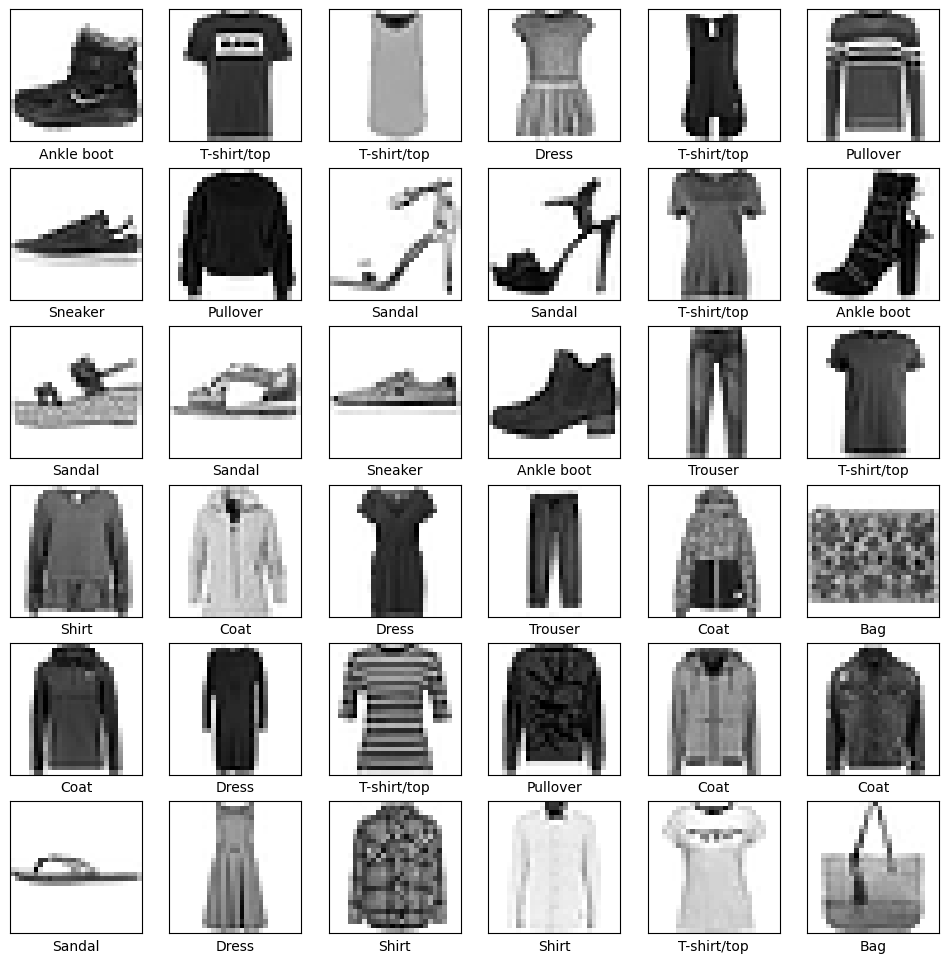

In [6]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
plt.figure(figsize=(12, 12))
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

This is very low resolution. Some things look very much the same, like pullover vs coat. 

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [42]:

from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create the simple baseline model
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))

# Layers
model.add(Dense(64, activation='relu', input_shape=(64,))) 
model.add(Dense(10, activation='softmax'))

# Print a summary of the model
model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # This loss function requires one-hot encoded labels
    metrics=['accuracy']
)

# Train the model using the one-hot encoded labels
history = model.fit(
    X_train,
    y_train_one_hot, # Use the one-hot encoded labels
    epochs=5,
    validation_split=0.2
)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_one_hot) # Use one-hot encoded test labels

print(f'\nTest Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy*100:.2f}%')


Model: "sequential_35"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_34 (Flatten)        (None, 784)               0         
                                                                 
 dense_88 (Dense)            (None, 64)                50240     
                                                                 
 dense_89 (Dense)            (None, 10)                650       
                                                                 
Total params: 50890 (198.79 KB)
Trainable params: 50890 (198.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/5
1500/1500 [==============================] - 1s 633us/step - loss: 0.5307 - accuracy: 0.8168 - val_loss: 0.4463 - val_accuracy: 0.8355
Epoch 2/5
1500/1500 [==============================] - 1s 593us/step - loss: 0.3974 - accuracy: 0.8589 - val_loss: 0.4097 - val_accura

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

This has 2 layers, a relu and a softmax, and it has pretty flat learning between 82-88%. Meh. I was hoping for a bit more of a curve, and greater accuracy. Also, by epoch 5 the accuracy is decreasing. 

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [43]:

from keras.layers import Conv2D, Flatten, Dense
from keras.models import Sequential

if len(X_train.shape) == 3:
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

model.add(Flatten())

# 3. Dense Layers: A standard fully-connected layer for classification.
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))

# 4. Output Layer: Produces the final probability for each of the 10 classes.
model.add(Dense(10, activation='softmax'))

# Print a summary of the model
model.summary()

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_one_hot, epochs=5, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_one_hot)

print(f'\nTest Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy*100:.2f}%')


Model: "sequential_36"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_27 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 flatten_35 (Flatten)        (None, 21632)             0         
                                                                 
 dense_90 (Dense)            (None, 64)                1384512   
                                                                 
 dense_91 (Dense)            (None, 64)                4160      
                                                                 
 dense_92 (Dense)            (None, 10)                650       
                                                                 
Total params: 1389642 (5.30 MB)
Trainable params: 1389642 (5.30 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/5
1500/

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Slightly better at 90% vs 88. I think spacial information is important if you want to understand how clothing components are related to each other, sleeves for example, or a hood, is a group of pixels that when grouped together make a characteristic. I think I want to experiement with the kernel size next. 

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.


--- Training with (3, 3) kernel size ---
Test Accuracy: 89.62%

--- Training with (4, 4) kernel size ---
Test Accuracy: 89.66%

--- Training with (5, 5) kernel size ---
Test Accuracy: 89.15%

--- Training with (6, 6) kernel size ---
Test Accuracy: 89.39%

--- Training with (7, 7) kernel size ---
Test Accuracy: 88.63%


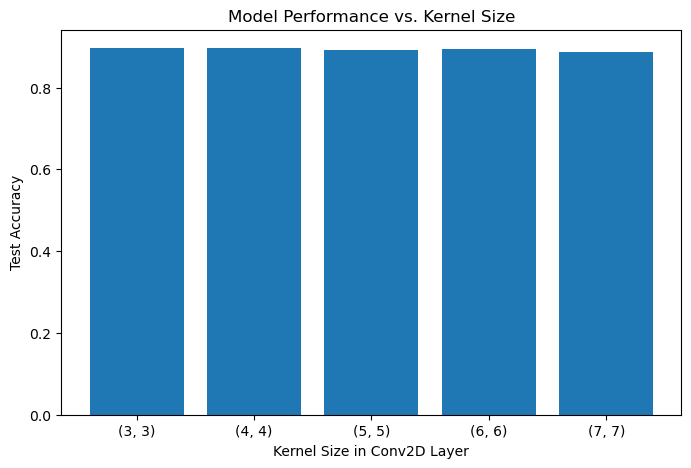

In [54]:

# A. Test Hyperparameters
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense


# different kernel sizes 
kernel_sizes = [(3, 3), (4, 4), (5, 5), (6, 6), (7, 7)]
results_kernel = {}

for k_size in kernel_sizes:
    print(f"\n--- Training with {k_size} kernel size ---")
    
    # Re-initialize the model for a fair comparison
    model = Sequential()
    # We keep the number of filters constant (e.g., 32) to isolate the effect of kernel size
    model.add(Conv2D(32, k_size, activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    
    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Train the model (using fewer epochs for faster experiments)
    model.fit(X_train, y_train_one_hot, epochs=5, validation_split=0.2, verbose=0)
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
    print(f"Test Accuracy: {accuracy*100:.2f}%")
    
    # Store the result (using a string for the dictionary key)
    results_kernel[str(k_size)] = accuracy

# --- Visualize the results ---
plt.figure(figsize=(8, 5))
plt.bar(results_kernel.keys(), results_kernel.values())
plt.xlabel("Kernel Size in Conv2D Layer")
plt.ylabel("Test Accuracy")
plt.title("Model Performance vs. Kernel Size")
plt.show()



--- Training without regularization ---
Test Accuracy without Dropout: 89.66%

--- Training with regularization ---
Test Accuracy with Dropout: 90.03%


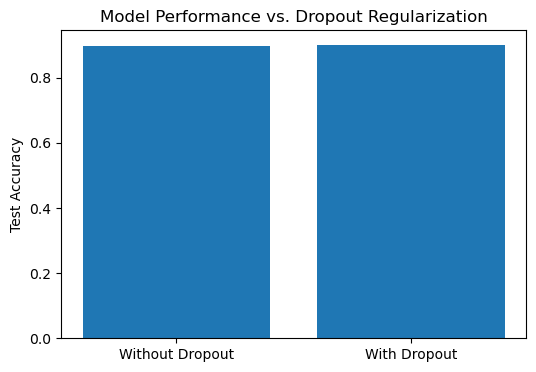

In [51]:


# B. Test presence or absence of regularization
from keras.layers import Dropout

# We will compare two models: one with Dropout and one without.
results_regularization = {}

# --- Model 1: No Regularization ---
print("\n--- Training without regularization ---")
model_no_reg = Sequential([
    Conv2D(32, (4, 4), activation='relu', input_shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_no_reg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_no_reg.fit(X_train, y_train_one_hot, epochs=10, validation_split=0.2, verbose=0)
loss, accuracy = model_no_reg.evaluate(X_test, y_test_one_hot, verbose=0)
print(f"Test Accuracy without Dropout: {accuracy*100:.2f}%")
results_regularization['Without Dropout'] = accuracy


# --- Model 2: With Dropout Regularization ---
print("\n--- Training with regularization ---")
model_with_reg = Sequential([
    Conv2D(32, (4, 4), activation='relu', input_shape=(28, 28, 1)),
    Flatten(),
    # Add a Dropout layer after the Dense layer. 0.3 means 30% of neurons will be dropped.
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_with_reg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_with_reg.fit(X_train, y_train_one_hot, epochs=10, validation_split=0.2, verbose=0)
loss, accuracy = model_with_reg.evaluate(X_test, y_test_one_hot, verbose=0)
print(f"Test Accuracy with Dropout: {accuracy*100:.2f}%")
results_regularization['With Dropout'] = accuracy

# --- Visualize the results ---
plt.figure(figsize=(6, 4))
plt.bar(results_regularization.keys(), results_regularization.values())
plt.ylabel("Test Accuracy")
plt.title("Model Performance vs. Dropout Regularization")
plt.show()


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

Kernel size: When I used an epoch of 5 it looked like 4 was the ideal kernel size, but with an epoch size of 10, all gains were washed away. I guess 10 epochs means model is overfitting with a larger kernel. I went back to only 5 Epochs across the board, but that became a problem when using dropout. I tried dropout of .3, .5, .7 and they were all worse than the model that didn't use dropout when using 5 epochs. When I spent the time to switch to 10 epochs, dropout of .7 was a tiny bit better (that 70% so very high), then .5 then .3, which turned out to be the best, reaching 90% accuracy.

I think smaller kernel like 4, larger epochs, dropout of 30% is the model I will try for part 5. 

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

--- Training Final Model ---
Epoch 1/15
1500/1500 [==============================] - 5s 3ms/step - loss: 0.5292 - accuracy: 0.8109 - val_loss: 0.3520 - val_accuracy: 0.8702
Epoch 2/15
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3616 - accuracy: 0.8699 - val_loss: 0.3124 - val_accuracy: 0.8859
Epoch 3/15
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3133 - accuracy: 0.8847 - val_loss: 0.3006 - val_accuracy: 0.8888
Epoch 4/15
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2719 - accuracy: 0.8989 - val_loss: 0.2864 - val_accuracy: 0.8966
Epoch 5/15
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2450 - accuracy: 0.9095 - val_loss: 0.2973 - val_accuracy: 0.8991
Epoch 6/15
1500/1500 [==============================] - 5s 4ms/step - loss: 0.2202 - accuracy: 0.9174 - val_loss: 0.2880 - val_accuracy: 0.9016
Epoch 7/15
1500/1500 [==============================] - 5s 3ms/step - loss: 0.1986 - accuracy: 0.9244 - val

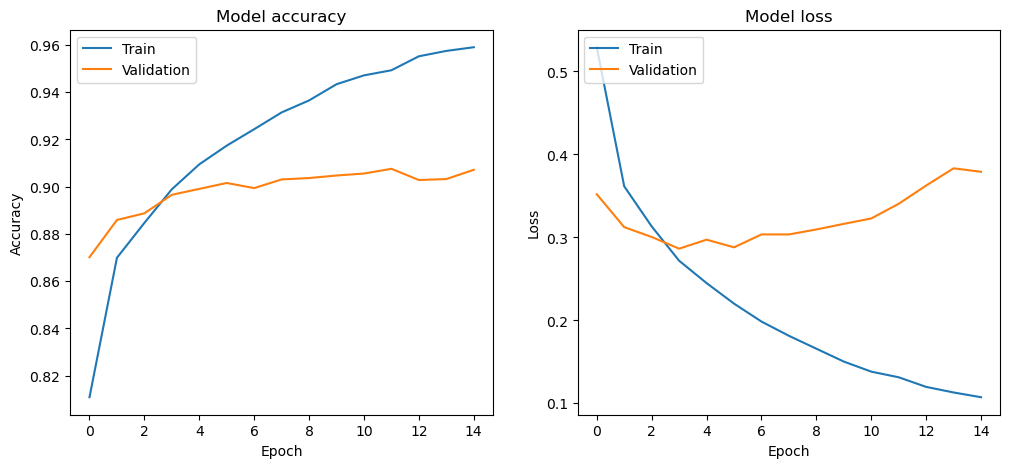

In [56]:

# 5. Training Final Model and Evaluation

from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# 1. Define the final model architecture using your best findings
# We'll use (4,4) as a good middle-ground, and add Dropout to fight overfitting.
final_model = Sequential([
    Conv2D(32, (4, 4), activation='relu', input_shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# 2. Compile the model
final_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 3. Train for more epochs to allow the regularized model to learn properly
print("--- Training Final Model ---")
history = final_model.fit(X_train, 
                          y_train_one_hot, 
                          epochs=15, 
                          validation_split=0.2,
                          verbose=1)

# 4. Evaluate the final model on the test set
loss, accuracy = final_model.evaluate(X_test, y_test_one_hot, verbose=0)

print(f'\nFinal Test Loss:     {loss:.4f}')
print(f'Final Test Accuracy: {accuracy*100:.2f}%')

# 5. Visualize the training history to check for overfitting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

I tried a 4,4 kernel then a layer with a 30% drop out followed by a relu as a hidden layer, and then a softmax output layer. Still middling and the graph indicated overfitting because the training accuracy increased but the valication rate didn't move much. The test data accuracy only moved from 87-90%. There are other methods to try like maxpooling which reduced overfitting and makes it run faster. Still the gains were 

Model: "sequential_64"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_56 (Conv2D)          (None, 25, 25, 32)        544       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 12, 12, 32)        0         
 g2D)                                                            
                                                                 
 flatten_63 (Flatten)        (None, 4608)              0         
                                                                 
 dense_174 (Dense)           (None, 64)                294976    
                                                                 
 dropout_17 (Dropout)        (None, 64)                0         
                                                                 
 dense_175 (Dense)           (None, 64)                4160      
                                                     

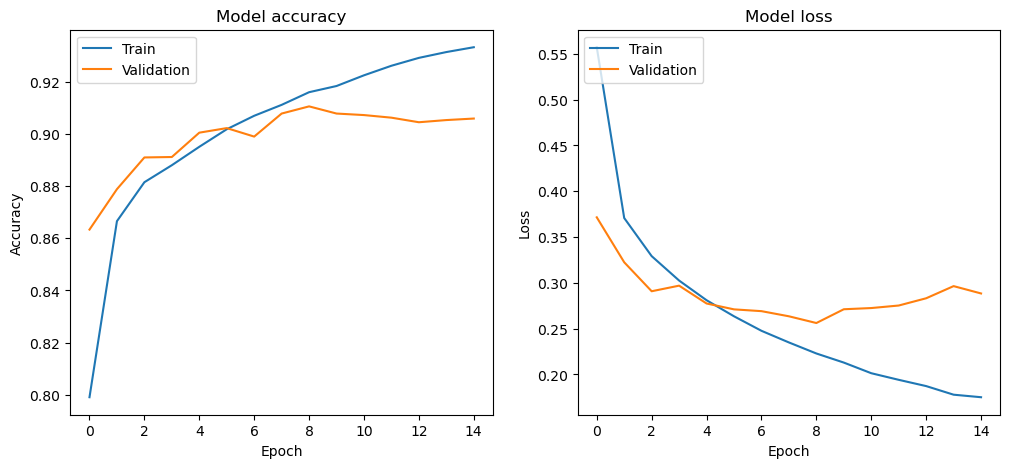

In [63]:
# Maxpooling.

from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D

model_with_maxpooling = Sequential([
    Conv2D(32, (4, 4), activation='relu', input_shape=(28, 28, 1)),
    # Add MaxPooling to downsample and regularize
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_with_maxpooling.summary()

model_with_maxpooling.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 3. Train for more epochs to allow the regularized model to learn properly
print("--- Training Final Model ---")
history = model_with_maxpooling.fit(X_train, 
                          y_train_one_hot, 
                          epochs=15, 
                          validation_split=0.2,
                          verbose=1)

# 4. Evaluate the final model on the test set
loss, accuracy = model_with_maxpooling.evaluate(X_test, y_test_one_hot, verbose=0)

print(f'\nFinal Test Loss:     {loss:.4f}')
print(f'Final Test Accuracy: {accuracy*100:.2f}%')

# 5. Visualize the training history to check for overfitting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Maxpooling brough some tiny gains of .1%. What about if we add 2 'convolutional blocks' that analyse simple features? To summarize it takes 3,3 kernel block, runs it through a relu, then simplifies it using max pooling, then it does the whole process again. This is breaking down features, like shape or texture, and then simplifiying them into a 2,2 snapshot of the most noticeable or measureable elements. Next we flatten and use a relu with dropout, which is the learning/classification component. This was suggested by copilot. We have arrived at 91.1%. I tried adding another dense layer, and that made it worse. This is where I stop fiddling : )

Model: "sequential_70"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_67 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 13, 13, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_68 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 5, 5, 64)          0         
 ng2D)                                                           
                                                                 
 flatten_69 (Flatten)        (None, 1600)              0         
                                                                 
 dense_188 (Dense)           (None, 128)             

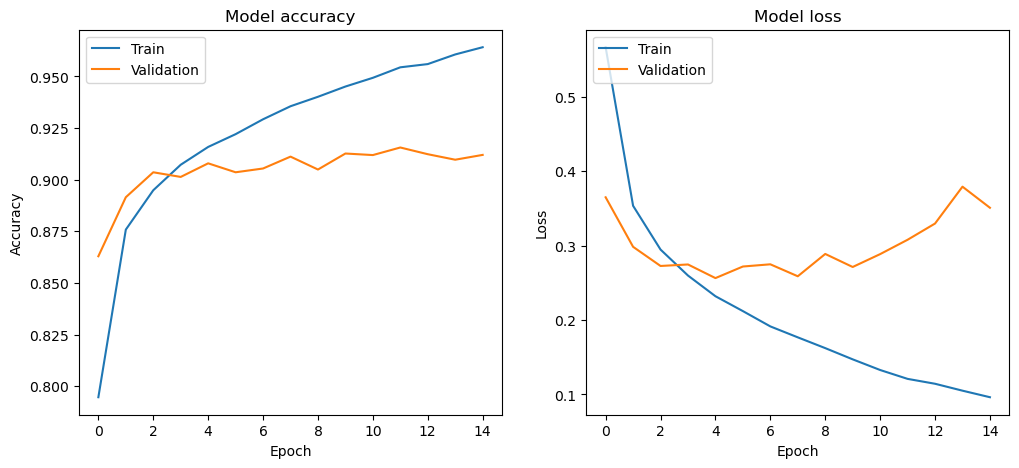

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D

two_conv_block_model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Classifier Head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Use a higher dropout rate for a more powerful classifier
    Dense(10, activation='softmax')
])

two_conv_block_model.summary()

two_conv_block_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 3. Train for more epochs to allow the regularized model to learn properly
print("--- Training Final Model ---")
history = two_conv_block_model.fit(X_train, 
                          y_train_one_hot, 
                          epochs=15, 
                          validation_split=0.2,
                          verbose=1)

# 4. Evaluate the final model on the test set
loss, accuracy = two_conv_block_model.evaluate(X_test, y_test_one_hot, verbose=0)

print(f'\nFinal Test Loss:     {loss:.4f}')
print(f'Final Test Accuracy: {accuracy*100:.2f}%')

# 5. Visualize the training history to check for overfitting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()




🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.